🎯 **Goal**: Improve classification performance by leveraging a pretrained convolutional neural network as a feature extractor.

**Approach**:

- Use MobileNetV2 pretrained on ImageNet as the base model
- Freeze the pretrained layers to retain learned visual features
- Add a lightweight classification head for the bird species task
- Train only the new top layers initially
- Evaluate performance against the baseline and log results using MLflow

MobileNetV2 / EfficientNetB0 / maybe ResNet50

### Imports

In [1]:
import os
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from beakspeak.data import load_metadata, split_data, create_dataset
from beakspeak.params import (
    IMG_HEIGHT,
    IMG_WIDTH,
    BATCH_SIZE,
    EPOCHS,
    LEARNING_RATE,
    SEED,
    NUM_CLASSES,
)

# --- MLFlow setup ---
import mlflow

mlflow.set_tracking_uri("sqlite:///../mlruns.db")
MLFLOW_EXPERIMENT_NAME = "beakspeak-transfer"
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

# --- Paths ---
DATA_DIR = Path("../data/CUB_200_2011/CUB_200_2011")

# --- tf performance ---
AUTOTUNE = tf.data.AUTOTUNE

# --- Checks ---
print("cwd:", os.getcwd())
print("tracking uri:", mlflow.get_tracking_uri())
print("resolved tracking path:", (Path.cwd() / "../mlruns").resolve())

cwd: /Users/keira/Documents/projects/beakspeak/notebooks
tracking uri: sqlite:///../mlruns.db
resolved tracking path: /Users/keira/Documents/projects/beakspeak/mlruns


In [2]:
# --- MLFlow helper function to plot and log curves ---

def plot_and_log_curves(history):
    import matplotlib.pyplot as plt
    import mlflow

    # --- extract metrics ---
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(len(acc))

    # --- Accuracy plot ---
    plt.figure()
    plt.plot(epochs_range, acc, label="Train Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy Curve")

    plt.savefig("accuracy_curve.png")
    mlflow.log_artifact("accuracy_curve.png")
    plt.close()

    # --- Loss plot ---
    plt.figure()
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss Curve")

    plt.savefig("loss_curve.png")
    mlflow.log_artifact("loss_curve.png")
    plt.close()

## Load the data

In [3]:
# Load and split the data
metadata_df = load_metadata(DATA_DIR)
train_df, val_df, test_df = split_data(metadata_df)

In [4]:
# Prepare labels for tf
train_df["label"] = train_df["class_id"] - 1
val_df["label"] = val_df["class_id"] - 1
test_df["label"] = test_df["class_id"] - 1

In [5]:
# Create train, test, val datasets
train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)
test_ds = create_dataset(test_df, shuffle=False)

## Working with MobileNetV2

### 🙋‍♀️ Why MobileNetV2

MobileNetV2 is a lightweight, widely used convolutional neural network pretrained on ImageNet, making it a strong starting point for transfer learning.

It is well-suited for this task because:
- it has already learned general visual features (edges, textures, shapes, object structure)
- it performs well on image classification tasks while remaining computationally efficient
- it is designed for input sizes of 224x224, aligning with the current preprocessing pipeline
- it provides a clear and interpretable step-up from the baseline CNN

Using MobileNetV2 allows us to test the impact of transfer learning in a clean and controlled way, before exploring more complex models or fine-tuning strategies.

In [6]:
def build_transfer_learning_model(num_classes):
    """
    Build a transfer learning model using MobileNetV2 as the feature extractor.
    """

    # Load MobileNetV2 with pretrained ImageNet weights
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,              # remove the classification head
        weights="imagenet"              # load pretrained weights
    )

    # Freeze the base model
    base_model.trainable = False

    # Create the classification head
    inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

    # Pass images through the base model
    x = base_model(inputs, training=False)

    # Global average pooling to reduce spatial dimensions
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    # Small dense layer for learning complex patterns
    x = tf.keras.layers.Dense(128, activation="relu")(x)

    # Dropout for regularization
    x = tf.keras.layers.Dropout(0.3)(x)

    # Output layer with softmax activation for multi-class classification
    outputs = tf.keras.layers.Dense(num_classes)(x)

    # Create the model
    model = tf.keras.Model(inputs, outputs)

    return model

In [7]:
# Build and compile the model
transfer_model = build_transfer_learning_model(NUM_CLASSES)

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

transfer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        25,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,447,752 (9.34 MB)

 Trainable params: 189,768 (741.28 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# Train the model and log metrics to MLflow
with mlflow.start_run():
    mlflow.log_param("model_type", "mobilenetv2_transfer")
    mlflow.log_param("base_model", "MobileNetV2")
    mlflow.log_param("frozen_base", True)
    mlflow.log_param("learning_rate", LEARNING_RATE)
    mlflow.log_param("epochs", EPOCHS)

    history = transfer_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS
    )

    plot_and_log_curves(history)

    val_loss, val_acc = transfer_model.evaluate(val_ds)
    test_loss, test_acc = transfer_model.evaluate(test_ds)

    mlflow.log_metric("val_loss", val_loss)
    mlflow.log_metric("val_accuracy", val_acc)
    mlflow.log_metric("test_loss", test_loss)
    mlflow.log_metric("test_accuracy", test_acc)

    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 34s 216ms/step - accuracy: 0.0405 - loss: 4.9462 - val_accuracy: 0.1393 - val_loss: 4.0774
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 36s 237ms/step - accuracy: 0.1658 - loss: 3.6823 - val_accuracy: 0.2811 - val_loss: 3.1133
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 42s 283ms/step - accuracy: 0.2740 - loss: 2.9333 - val_accuracy: 0.3119 - val_loss: 2.7329
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 55s 364ms/step - accuracy: 0.3558 - loss: 2.4797 - val_accuracy: 0.3586 - val_loss: 2.5359
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 53s 356ms/step - accuracy: 0.4313 - loss: 2.1365 - val_accuracy: 0.3786 - val_loss: 2.3887
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 260ms/step - accuracy: 0.3786 - loss: 2.3887
182/182 ━━━━━━━━━━━━━━━━━━━━ 48s 264ms/step - accuracy: 0.3902 - loss: 2.3676
Validation Accuracy: 0.3786
Test Accuracy: 0.3902


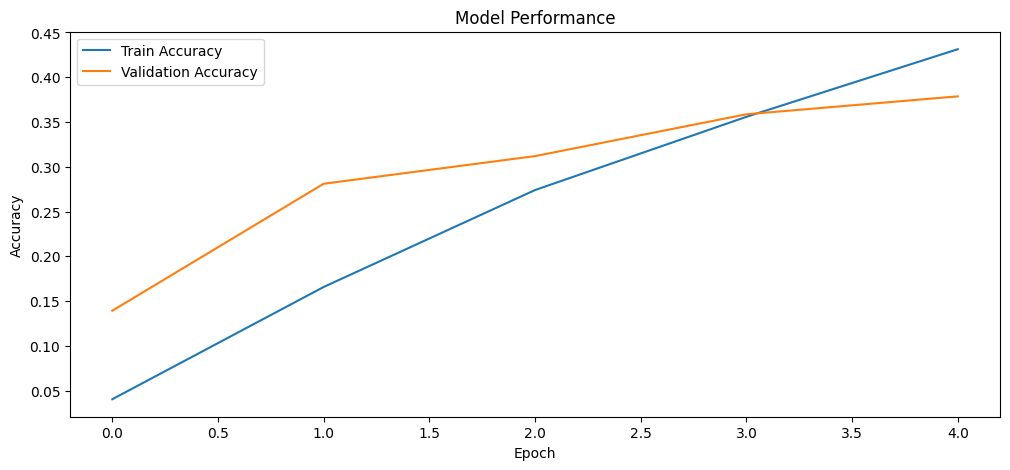

In [9]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 5))
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Performance")
plt.legend()
plt.show()

🙋‍♀️ **What next?**

The transfer learning model dramatically outperforms the baseline, reaching ~38% validation and test accuracy after 5 epochs (vs 5% baseline). Unlike the baseline CNN, this model shows clear signs of learning: training accuracy increases steadily, validation accuracy improves each epoch, and validation loss continues to fall.

This suggests that the pretrained MobileNetV2 backbone is providing useful visual features that transfer effectively to the bird classification task. Despite having fewer trainable parameters than the baseline model(*), it performs far better, highlighting that model quality and prior knowledge matter more than parameter count alone.

As validation performance was still improving at the end of training, the next step is to extend training with early stopping so the model can continue improving without overtraining.

----

(*) *The baseline model had more trainable parameters largely because Flatten + Dense layers are parameter-heavy, whereas the transfer model uses a frozen pretrained backbone plus a compact classification head.*

### MobileNetV2 + Extended Training

Epochs 🔼

In [10]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
with mlflow.start_run(run_name="mobilenetv2_frozen_es"):
    mlflow.log_param("model_type", "mobilenetv2_transfer")
    mlflow.log_param("base_model", "MobileNetV2")
    mlflow.log_param("frozen_base", True)
    mlflow.log_param("learning_rate", LEARNING_RATE)
    mlflow.log_param("epochs", 15)
    mlflow.log_param("early_stopping", True)
    mlflow.log_param("early_stopping_monitor", "val_loss")
    mlflow.log_param("early_stopping_patience", 3)
    mlflow.log_param("restore_best_weights", True)

    history = transfer_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        callbacks=[early_stopping]
    )

    plot_and_log_curves(history)

    val_loss, val_acc = transfer_model.evaluate(val_ds)
    test_loss, test_acc = transfer_model.evaluate(test_ds)

    mlflow.log_metric("val_loss", val_loss)
    mlflow.log_metric("val_accuracy", val_acc)
    mlflow.log_metric("test_loss", test_loss)
    mlflow.log_metric("test_accuracy", test_acc)

    best_val_accuracy = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])

    mlflow.log_metric("best_val_accuracy", best_val_accuracy)
    mlflow.log_metric("best_val_loss", best_val_loss)
    mlflow.log_metric("test_accuracy", test_acc)
    mlflow.log_metric("test_loss", test_loss)

    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
    print(f"Best Validation Loss: {best_val_loss:.4f}")

Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 48s 323ms/step - accuracy: 0.4767 - loss: 1.9325 - val_accuracy: 0.3937 - val_loss: 2.2915
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 48s 318ms/step - accuracy: 0.5303 - loss: 1.7056 - val_accuracy: 0.3937 - val_loss: 2.2525
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 49s 329ms/step - accuracy: 0.5664 - loss: 1.5709 - val_accuracy: 0.4145 - val_loss: 2.1830
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 47s 311ms/step - accuracy: 0.6081 - loss: 1.4078 - val_accuracy: 0.4178 - val_loss: 2.1890
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 43s 288ms/step - accuracy: 0.6342 - loss: 1.3058 - val_accuracy: 0.4245 - val_loss: 2.1490
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 41s 271ms/step - accuracy: 0.6517 - loss: 1.2155 - val_accuracy: 0.4262 - val_loss: 2.1883
Epoch 7/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 41s 273ms/step - accuracy: 0.6772 - loss: 1.1234 - val_accuracy: 0.4295 - val_loss: 2.1365
Epoch 8/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 41s 271ms/step - accuracy: 0.7141 - loss: 1

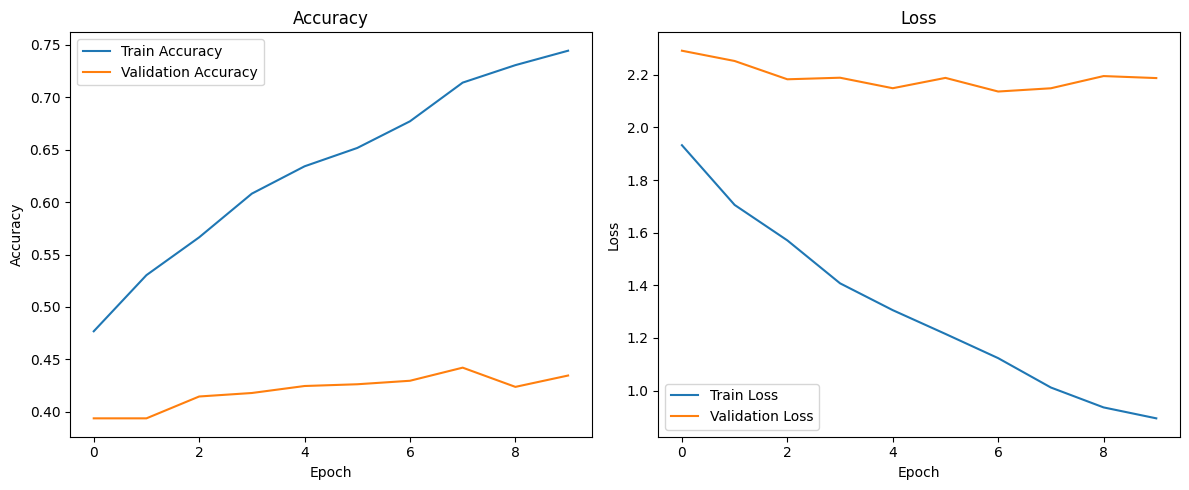

In [11]:
# --- PLOT PERFORMANCE ---

# --- extract values ---
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(len(acc))

# --- create figure ---
plt.figure(figsize=(12, 5))

# ===== Accuracy plot =====
plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
plt.plot(epochs, acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# ===== Loss plot =====
plt.subplot(1, 2, 2)  # second plot
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# --- display ---
plt.tight_layout()
plt.show()

### 💡 Transfer Learning (Extended Training) - Performance & Interpretation

Extending training beyond the initial 5-epoch run leads to further improvements, with validation accuracy increasing from ~38% to ~41.9% and test accuracy to ~44.2%. This confirms that the transfer learning approach is effective and still had room to improve.

However, the learning curves show a clear shift in behaviour. Early epochs continue to improve both training and validation performance, but from around epoch 4–6 onwards, validation accuracy plateaus while training accuracy continues to rise. Validation loss also stops improving and begins to drift upwards.

This indicates **the model is starting to overfit** and has reached the limit of what can be achieved with a frozen pretrained backbone. Additional training alone is no longer improving generalisation.

Early stopping (patience=3) halted training after 9 epochs, restoring the model to the point of lowest validation loss.

At this stage, the approach is validated but constrained. 

👉 The next step is to increase model flexibility by fine-tuning the upper layers of MobileNetV2, allowing the feature extractor to adapt to the fine-grained differences between bird species.

## Fine-Tuning

The previous experiments show that transfer learning provides a strong foundation, but performance plateaus when the pretrained backbone is frozen.

To improve further, the model needs to adapt its feature representations to the specific characteristics of the dataset. This is particularly important for fine-grained classification tasks, where subtle visual differences matter.

In this step, the upper layers of MobileNetV2 are unfrozen and trained with a lower learning rate, allowing the model to refine its features without disrupting the pretrained weights.

In [12]:
# Show the top-level layers in the transfer model
for i, layer in enumerate(transfer_model.layers):
    print(i, layer.name, layer.trainable)

0 input_layer_1 True
1 mobilenetv2_1.00_224 False
2 global_average_pooling2d True
3 dense True
4 dropout True
5 dense_1 True


In [13]:
# Access pre-trained base model layers
base_model = transfer_model.layers[1]

print(base_model.name)
print("Number of layers in base model:", len(base_model.layers))

mobilenetv2_1.00_224
Number of layers in base model: 154


In [14]:
# Unfreeze the base model
base_model.trainable = True

# Selectively unfreeze layers to fine-tune
fine_tune_at = len(base_model.layers) - 30

# Freeze all layers before the fine-tune point
for i, layer in enumerate(base_model.layers):
    if i < fine_tune_at:
        layer.trainable = False
    else:
        # Keep BatchNorm layers frozen to prevent training instability
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

# Confirm trainable status of last few layers
for layer in base_model.layers[-10:]:
    print(layer.name, layer.trainable)

# Count trainable vs non-trainable weights
print("Trainable weights:", len(transfer_model.trainable_weights))
print("Non-trainable weights:", len(transfer_model.non_trainable_weights))

block_16_expand_BN False
block_16_expand_relu True
block_16_depthwise True
block_16_depthwise_BN False
block_16_depthwise_relu True
block_16_project True
block_16_project_BN False
Conv_1 True
Conv_1_bn False
out_relu True
Trainable weights: 14
Non-trainable weights: 250


In [15]:
# Recompile the model with a lower learning rate for fine-tuning
FINE_TUNE_LEARNING_RATE = 1e-5
FINE_TUNE_EPOCHS = 15

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# Early stopping callback for fine-tuning
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Set up MLflow for fine-tuning run
with mlflow.start_run(run_name="mobilenetv2_finetune_top30"):
    mlflow.log_param("model_type", "mobilenetv2_finetune")
    mlflow.log_param("base_model", "MobileNetV2")
    mlflow.log_param("frozen_base", False)
    mlflow.log_param("learning_rate", FINE_TUNE_LEARNING_RATE)
    mlflow.log_param("epochs", FINE_TUNE_EPOCHS)
    mlflow.log_param("early_stopping", True)
    mlflow.log_param("early_stopping_monitor", "val_loss")
    mlflow.log_param("early_stopping_patience", 3)
    mlflow.log_param("restore_best_weights", True)
    mlflow.log_param("batchnorm_frozen", True)


    # Train the model with fine-tuning and early stopping
    fine_tune_history = transfer_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=[early_stopping]
    )

    plot_and_log_curves(fine_tune_history)

    # Evaluate the model on validation and test sets
    val_loss, val_accuracy = transfer_model.evaluate(val_ds, verbose=0)
    test_loss, test_accuracy = transfer_model.evaluate(test_ds, verbose=0)

    mlflow.log_metric("val_loss", val_loss)
    mlflow.log_metric("val_accuracy", val_accuracy)
    mlflow.log_metric("test_loss", test_loss)
    mlflow.log_metric("test_accuracy", test_accuracy)

    best_val_accuracy = max(fine_tune_history.history["val_accuracy"])
    best_val_loss = min(fine_tune_history.history["val_loss"])

    mlflow.log_metric("best_val_accuracy", best_val_accuracy)
    mlflow.log_metric("best_val_loss", best_val_loss)

    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
    print(f"Best Validation Loss: {best_val_loss:.4f}")

Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 47s 297ms/step - accuracy: 0.7460 - loss: 0.8922 - val_accuracy: 0.4312 - val_loss: 2.1596
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 48s 318ms/step - accuracy: 0.7627 - loss: 0.8142 - val_accuracy: 0.4379 - val_loss: 2.1567
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 46s 307ms/step - accuracy: 0.7702 - loss: 0.7769 - val_accuracy: 0.4337 - val_loss: 2.1610
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 45s 301ms/step - accuracy: 0.7883 - loss: 0.7319 - val_accuracy: 0.4387 - val_loss: 2.1668
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 45s 301ms/step - accuracy: 0.7965 - loss: 0.7080 - val_accuracy: 0.4437 - val_loss: 2.1544
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 46s 304ms/step - accuracy: 0.8100 - loss: 0.6700 - val_accuracy: 0.4454 - val_loss: 2.1738
Epoch 7/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 46s 307ms/step - accuracy: 0.8140 - loss: 0.6507 - val_accuracy: 0.4445 - val_loss: 2.1616
Epoch 8/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 46s 305ms/step - accuracy: 0.8330 - loss: 0

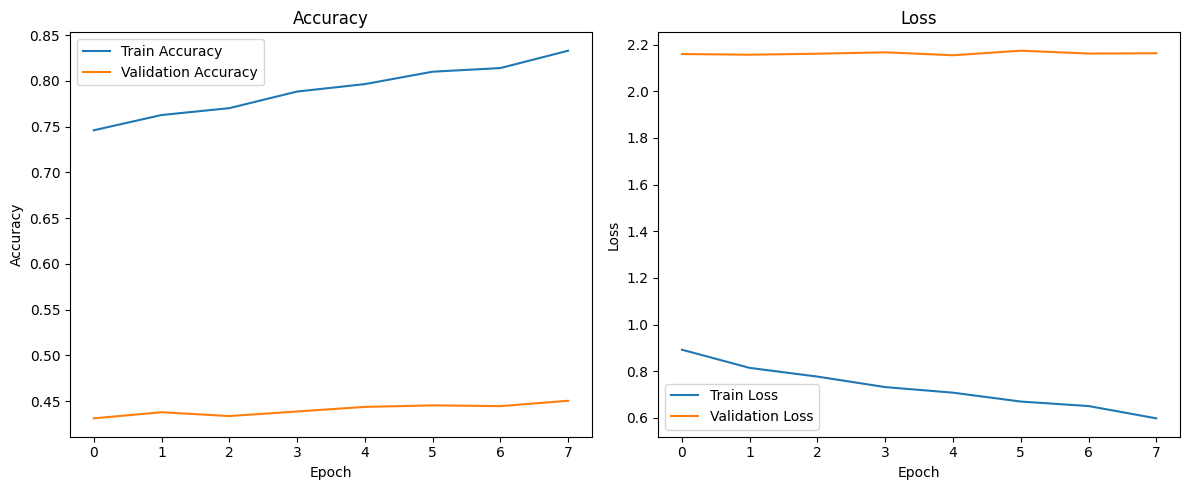

In [16]:
# --- PLOT PERFORMANCE ---

# --- extract values ---
acc = fine_tune_history.history["accuracy"]
val_acc = fine_tune_history.history["val_accuracy"]

loss = fine_tune_history.history["loss"]
val_loss = fine_tune_history.history["val_loss"]

epochs = range(len(acc))

# --- create figure ---
plt.figure(figsize=(12, 5))

# ===== Accuracy plot =====
plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
plt.plot(epochs, acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# ===== Loss plot =====
plt.subplot(1, 2, 2)  # second plot
plt.plot(epochs, loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# --- display ---
plt.tight_layout()
plt.show()